# Rabbits and foxes

There are initially 400 rabbits and 200 foxes on a farm (but it could be two cell types in a 96 well plate or something, if you prefer bio-engineering analogies). Plot the concentration of foxes and rabbits as a function of time for a period of up to 600 days. The predator-prey relationships are given by the following set of coupled ordinary differential equations:

\begin{align}
\frac{dR}{dt} &= k_1 R - k_2 R F \tag{1}\\
\frac{dF}{dt} &= k_3 R F - k_4 F \tag{2}\\
\end{align}

* Constant for growth of rabbits $k_1 = 0.015$ day<sup>-1</sup>
* Constant for death of rabbits being eaten by foxes $k_2 = 0.00004$ day<sup>-1</sup> foxes<sup>-1</sup>
* Constant for growth of foxes after eating rabbits $k_3 = 0.0004$ day<sup>-1</sup> rabbits<sup>-1</sup>
* Constant for death of foxes $k_4 = 0.04$ day<sup>-1</sup>

Also plot the number of foxes versus the number of rabbits.

Then try also with 
* $k_3 = 0.00004$ day<sup>-1</sup> rabbits<sup>-1</sup>
* $t_{final} = 800$ days

*This problem is based on one from Chapter 1 of H. Scott Fogler's textbook "Essentials of Chemical Reaction Engineering".*


# Solving ODEs

*Much of the following content reused under Creative Commons Attribution license CC-BY 4.0, code under MIT license (c)2014 L.A. Barba, G.F. Forsyth. Partly based on David Ketcheson's pendulum lesson, also under CC-BY. https://github.com/numerical-mooc/numerical-mooc*

Let's step back for a moment. Suppose we have a first-order ODE $u'=f(u)$. You know that if we were to integrate this, there would be an arbitrary constant of integration. To find its value, we do need to know one point on the curve $(t, u)$. When the derivative in the ODE is with respect to time, we call that point the _initial value_ and write something like this:

$$u(t=0)=u_0$$

In the case of a second-order ODE, we already saw how to write it as a system of first-order ODEs, and we would need an initial value for each equation: two conditions are needed to determine our constants of integration. The same applies for higher-order ODEs: if it is of order $n$, we can write it as $n$ first-order equations, and we need $n$ known values. If we have that data, we call the problem an _initial value problem_.

Remember the definition of a derivative? The derivative represents the slope of the tangent at a point of the curve $u=u(t)$, and the definition of the derivative $u'$ for a function is:

$$u'(t) = \lim_{\Delta t\rightarrow 0} \frac{u(t+\Delta t)-u(t)}{\Delta t}$$

If the step $\Delta t$ is already very small, we can _approximate_ the derivative by dropping the limit. We can write:

$$\begin{equation}
u(t+\Delta t) \approx u(t) + u'(t) \Delta t
\end{equation}$$

With this equation, and because we know $u'(t)=f(u)$, if we have an initial value, we can step by $\Delta t$ and find the value of $u(t+\Delta t)$, then we can take this value, and find $u(t+2\Delta t)$, and so on: we say that we _step in time_, numerically finding the solution $u(t)$ for a range of values: $t_1, t_2, t_3 \cdots$, each separated by $\Delta t$. The numerical solution of the ODE is simply the table of values $t_i, u_i$ that results from this process.


# Euler's method
*Also known as "Simple Euler" or sometimes "Simple Error".*

The approximate solution at time $t_n$ is $u_n$, and the numerical solution of the differential equation consists of computing a sequence of approximate solutions by the following formula, based on Equation (10):

$$u_{n+1} = u_n + \Delta t \,f(u_n).$$

This formula is called **Euler's method**.

For the equations of the rabbits and foxes, Euler's method gives the following algorithm that we need to implement in code:

\begin{align}
R_{n+1} & = R_n + \Delta t \left(k_1 R_n - k_2 R_n F_n \right) \\
F_{n+1} & = F_n + \Delta t \left( k_3 R_n F_n - k_4 F_n \right).
\end{align}


In [1]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

Here is one way to do it. Not necessarily the best, but it'll work:

In [2]:
k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04
end_time = 600.
step_size = 1.
times = np.arange(0, end_time, step_size)
rabbits = np.zeros_like(times)
foxes = np.zeros_like(times)
rabbits[0] = 400.
foxes[0] = 200.
for n in range(len(times)-1):
    delta_t = times[n+1] - times[n]
    rabbits[n+1] = rabbits[n] + delta_t * (k1 * rabbits[n] - k2 * rabbits[n] * foxes[n])
    foxes[n+1] = foxes[n] + delta_t * (k3 * rabbits[n] * foxes[n] - k4 * foxes[n])

Now let's plot the results.

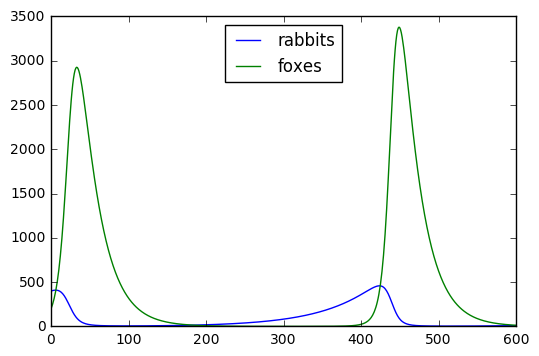

In [3]:
plt.plot(times, rabbits, label='rabbits')
plt.plot(times, foxes, label='foxes')
plt.legend(loc="best") # put the legend at the best location to avoid overlapping things
plt.show()

Now let's copy and paste the code above, and turn it into a function so we can evaluate it with many different step sizes. In order to compare the different results we need to pick some quantity of interest. We'll choose the maximum number of foxes, because it's simple to find and presumably interesting, although if you care more about the time at which the maximum occurs, or the number of rabbits, or something else, then use that instead.

In [4]:
k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04
def solve_by_euler(step_size = 1.):
    """
    Evaluate by simple Euler, with the given step size.
    
    Returns the peak number of foxes.
    """
    end_time = 600.
    times = np.arange(0, end_time, step_size)
    rabbits = np.zeros_like(times)
    foxes = np.zeros_like(times)
    rabbits[0] = 400
    foxes[0] = 200
    for n in range(len(times)-1):
        delta_t = times[n+1] - times[n]
        rabbits[n+1] = rabbits[n] + delta_t * (k1 * rabbits[n] - k2 * rabbits[n] * foxes[n])
        foxes[n+1] = foxes[n] + delta_t * (k3 * rabbits[n] * foxes[n] - k4 * foxes[n])
    return foxes.max()

step_sizes = []
maximums = []
for i in range(20):
    print(i)
    step_size = 10**(1-i/5)
    print("step size",step_size)
    maximum = solve_by_euler(step_size)
    print("max foxes",maximum)
    step_sizes.append(step_size)
    maximums.append(maximum)

0
step size 10.0
max foxes 9998.78475782
1
step size 6.309573444801933
max foxes 3757.41265232
2
step size 3.9810717055349722
max foxes 6831.75851318
3
step size 2.51188643150958
max foxes 4686.90809525
4
step size 1.5848931924611134
max foxes 3801.65788402
5
step size 1.0
max foxes 3379.27631701
6
step size 0.6309573444801934
max foxes 3146.04098438
7
step size 0.3981071705534973
max foxes 3012.6379837
8
step size 0.25118864315095796
max foxes 2932.87919521
9
step size 0.15848931924611134
max foxes 2884.18652591
10
step size 0.1
max foxes 2854.12476091
11
step size 0.0630957344480193
max foxes 2835.41436334
12
step size 0.039810717055349734
max foxes 2823.7085615
13
step size 0.025118864315095794
max foxes 2816.36116277
14
step size 0.01584893192461114
max foxes 2811.74114081
15
step size 0.01
max foxes 2808.83241288
16
step size 0.00630957344480193
max foxes 2806.99952212
17
step size 0.003981071705534973
max foxes 2805.84398119
18
step size 0.0025118864315095794
max foxes 2805.11527

Let's plot on a semi-logarithmic plot (log scale on the x axis) and see what it looks like.

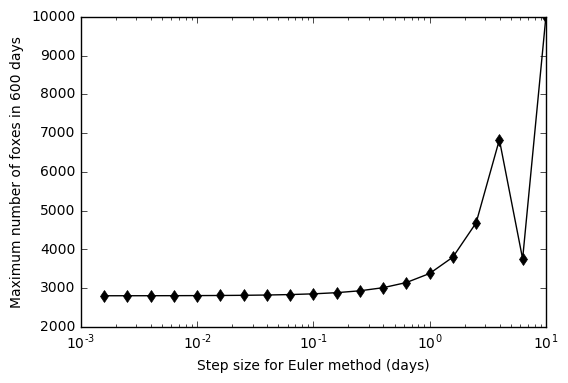

In [5]:
plt.semilogx(step_sizes, maximums, 'kd-')
plt.ylabel("Maximum number of foxes in 600 days")
plt.xlabel("Step size for Euler method (days)")
plt.show()

Smaller step sizes give more accurate results, and we see it converges towards the "true" solution as we go left on the graph. Let's assume the smallest we tried is in fact "true", and calculate the errors relative to this. Then plot those against step size on a log-log plot. The slope should give us the order of convergence of the method.

In [6]:
maximums = np.array(maximums)
errors = maximums - maximums[-1] # calculate error relative to the last value

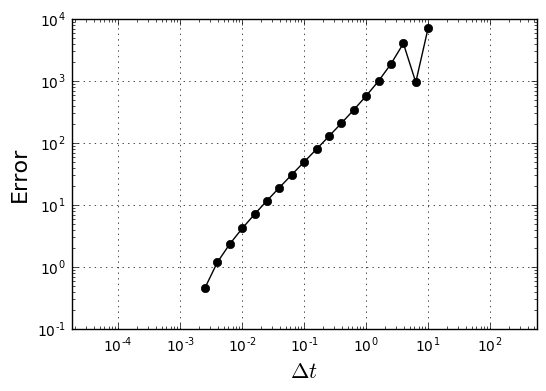

In [7]:
# plot all but the last point, because log(0.0) will cause problems scaling the axes
plt.loglog(step_sizes[:-1], errors[:-1], 'ko-')

plt.axis('equal') # scale the axes to make a square a square
plt.grid(True) # turn on the grid lines
plt.xlabel("$\Delta t$", fontsize=16)
plt.ylabel("Error", fontsize=16)
plt.show()

The straight line slope of 1 shows that Simple Euler is a first order algorithm. 
We only get below an error of $10^0$ (1.0) in this quantity of interest with the second smallest step size, $\sim$0.002.
The Euler method is not very good - it requires tiny steps and converges slowly. You might have heard of (and might like to try) some [Ruge-Kutta](https://en.wikipedia.org/wiki/Runge–Kutta_methods) methods. If you do, first set up the right hand side of the ODE as a function, because you'll need to call it repeatedly within a single iteration.

# Let's solve this with a better ODE integrator

We'll use `odeint` from the `scipy.integrate` package. Check its documentation for details.

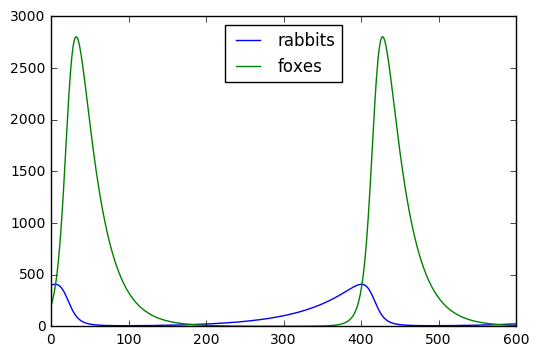

Second peak occurs at (428, 2803.6080735671562)


In [8]:
from scipy.integrate import odeint

k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04
end_time = 600.

def rates(variables, time):
    """
    Return the right hand side of the ODE
    """
    rabbits, foxes = variables
    rate_rabbits = (k1 * rabbits - k2 * rabbits * foxes)
    rate_foxes = (k3 * rabbits * foxes - k4 * foxes)
    return (rate_rabbits, rate_foxes)

times = np.arange(0, end_time)
initial_conditions = (400., 200.)
result = odeint(rates, initial_conditions, times)
rabbits = result[:,0]
foxes = result[:,1]
plt.plot(times, rabbits, label='rabbits')
plt.plot(times, foxes, label='foxes')
plt.legend(loc="best") # put the legend at the best location to avoid overlapping things
plt.show()
print("Second peak occurs at",(foxes.argmax(),foxes.max()))
